# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


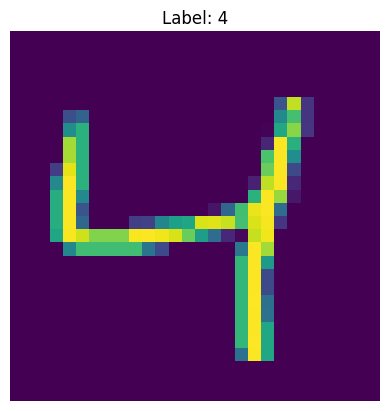

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [6]:
# ANN 객체 생성
input_dim = 784  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [7]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.1068824753165245  Accuracy: 96.08872985839844 %
Iteration: 1000  Loss: 0.07039672136306763  Accuracy: 97.1978988647461 %
Iteration: 1500  Loss: 0.02685125358402729  Accuracy: 97.41194915771484 %
Iteration: 2000  Loss: 0.0657820999622345  Accuracy: 97.84004974365234 %
Iteration: 2500  Loss: 0.082169309258461  Accuracy: 97.97625732421875 %
Iteration: 3000  Loss: 0.14471326768398285  Accuracy: 98.01517486572266 %
Iteration: 3500  Loss: 0.06823232024908066  Accuracy: 98.24868774414062 %
Iteration: 4000  Loss: 0.02502240054309368  Accuracy: 98.46273803710938 %
Iteration: 4500  Loss: 0.047380231320858  Accuracy: 98.5794906616211 %


#### **ANN 학습 결과**

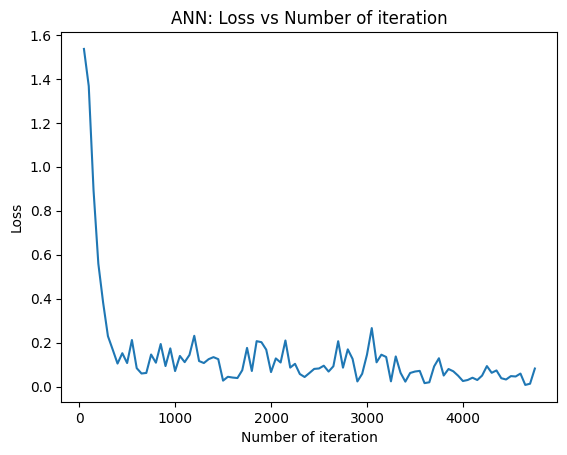

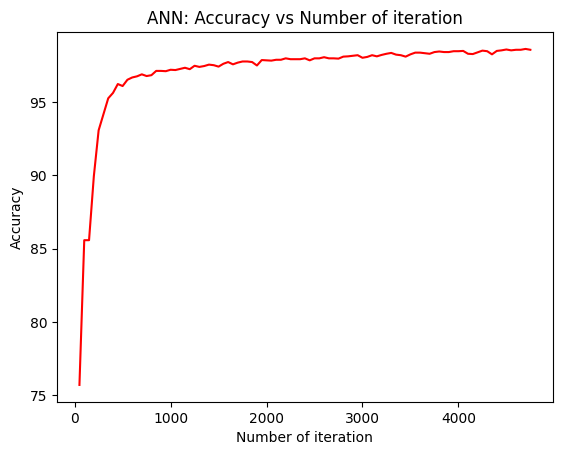

In [8]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
-
- 시각화된 그래프를 보면, 반복 횟수(iteration)가 증가함에 따라 손실(Loss)은 점차 감소하고 정확도(Accuracy)는 꾸준히 증가하는 것을 확인할 수 있음.
- 이를 통해 모델이 훈련 데이터를 성공적으로 학습하고 있으며, 시간이 지남에 따라 예측 성능이 향상되고 있음을 확인할 수 있음.
-  특히, 손실 값이 대부분 0.2이하로 유지되며 정확도는 95이상의 값으로 증가하고 있음을 통해 모델이 안정적으로 학습되고 있음을 알 수 있다.


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [9]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
hidden_dims = [50, 100, 150, 200]
results = {}

for hidden_dim in hidden_dims:
    model = ANNModel(input_dim,hidden_dim,output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    learning_rate = 0.02
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []
    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1
            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)
            if count % 500 == 0:
                print('Hidden dim:{}  Iteration: {}  Loss: {}  Accuracy: {} %'.format(hidden_dim, count, loss.data, accuracy))
    results[hidden_dim] = (iteration_list, loss_list, accuracy_list)


Hidden dim:50  Iteration: 500  Loss: 0.18668816983699799  Accuracy: 95.58280181884766 %
Hidden dim:50  Iteration: 1000  Loss: 0.07635670155286789  Accuracy: 96.7697982788086 %
Hidden dim:50  Iteration: 1500  Loss: 0.06107303872704506  Accuracy: 97.31465148925781 %
Hidden dim:50  Iteration: 2000  Loss: 0.04623451083898544  Accuracy: 97.74275207519531 %
Hidden dim:50  Iteration: 2500  Loss: 0.10323085635900497  Accuracy: 97.84004974365234 %
Hidden dim:50  Iteration: 3000  Loss: 0.03612508624792099  Accuracy: 97.99571990966797 %
Hidden dim:50  Iteration: 3500  Loss: 0.07261320948600769  Accuracy: 98.1319351196289 %
Hidden dim:50  Iteration: 4000  Loss: 0.03653298690915108  Accuracy: 98.2292251586914 %
Hidden dim:50  Iteration: 4500  Loss: 0.01107740867882967  Accuracy: 98.30706024169922 %
Hidden dim:100  Iteration: 500  Loss: 0.3080472946166992  Accuracy: 96.06927490234375 %
Hidden dim:100  Iteration: 1000  Loss: 0.05101688951253891  Accuracy: 97.12006378173828 %
Hidden dim:100  Iteration

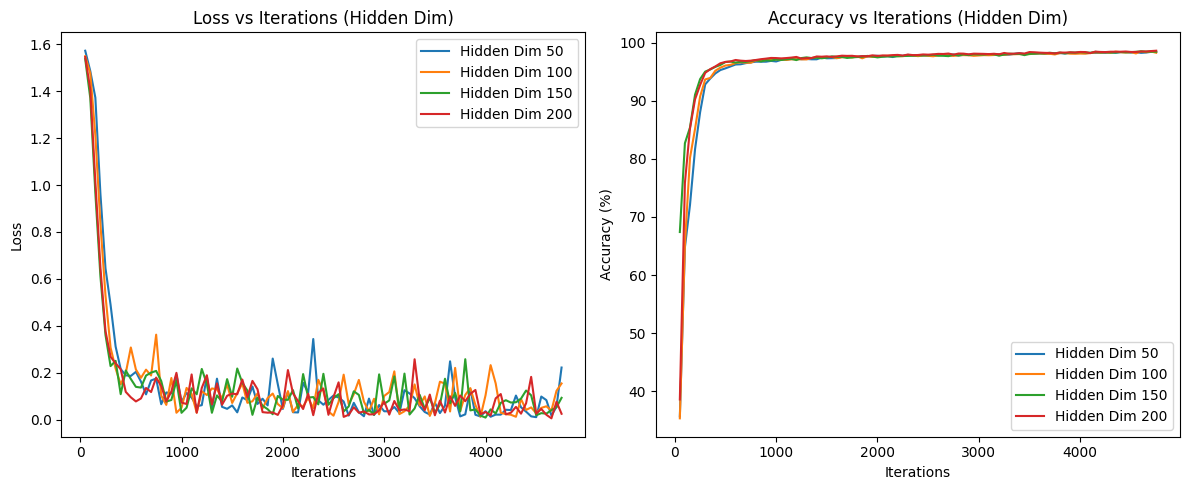

In [11]:
# 실험 1 모델 학습 결과 시각화
## 답안 ##
plt.figure(figsize=(12,5))
# loss 시각화
plt.subplot(1, 2, 1)
for hidden_dim, (iters, losses, accs) in results.items():
    plt.plot(iters, losses, label=f'Hidden Dim {hidden_dim}')

plt.title('Loss vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()


# accuracy 시각화
plt.subplot(1, 2, 2)
for hidden_dim, (iters, losses, accs) in results.items():
    plt.plot(iters, accs, label=f'Hidden Dim {hidden_dim}')

plt.title('Accuracy vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- hidden dimesion에 따라 초기 loss 감소량이 커지고 더 낮은 loss값에 수렴한다.
- hidden dimension값이 커질 수록 더 빠르게 정확도가 높아진다.
- hidden dimension이 커질수록 더 안정적인모델 학습이 이뤄지는것을 확인할 수 있다.

In [14]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
## 답안 ##
learning_rates = [0.1, 0.05, 0.02, 0.005]
results = {}

for lr in learning_rates:
    model = ANNModel(input_dim, hidden_dim, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

            if count % 500 == 0:
                print(f'Learning rate:{lr} Iteration: {count} Loss: {loss.item()} Accuracy: {accuracy} %')

    results[lr] = (iteration_list, loss_list, accuracy_list)

Learning rate:0.1 Iteration: 500 Loss: 0.054953865706920624 Accuracy: 97.58708190917969 %
Learning rate:0.1 Iteration: 1000 Loss: 0.07462328672409058 Accuracy: 98.30706024169922 %
Learning rate:0.1 Iteration: 1500 Loss: 0.04002733528614044 Accuracy: 98.89083099365234 %
Learning rate:0.1 Iteration: 2000 Loss: 0.008065449073910713 Accuracy: 99.06596374511719 %
Learning rate:0.1 Iteration: 2500 Loss: 0.012854574248194695 Accuracy: 99.24109649658203 %
Learning rate:0.1 Iteration: 3000 Loss: 0.011002503335475922 Accuracy: 99.31893157958984 %
Learning rate:0.1 Iteration: 3500 Loss: 0.006030069664120674 Accuracy: 99.24109649658203 %
Learning rate:0.1 Iteration: 4000 Loss: 0.001190246781334281 Accuracy: 99.29947662353516 %
Learning rate:0.1 Iteration: 4500 Loss: 0.0022084456868469715 Accuracy: 99.43568420410156 %
Learning rate:0.05 Iteration: 500 Loss: 0.07416217029094696 Accuracy: 97.43140411376953 %
Learning rate:0.05 Iteration: 1000 Loss: 0.05893357843160629 Accuracy: 97.95680236816406 %
Le

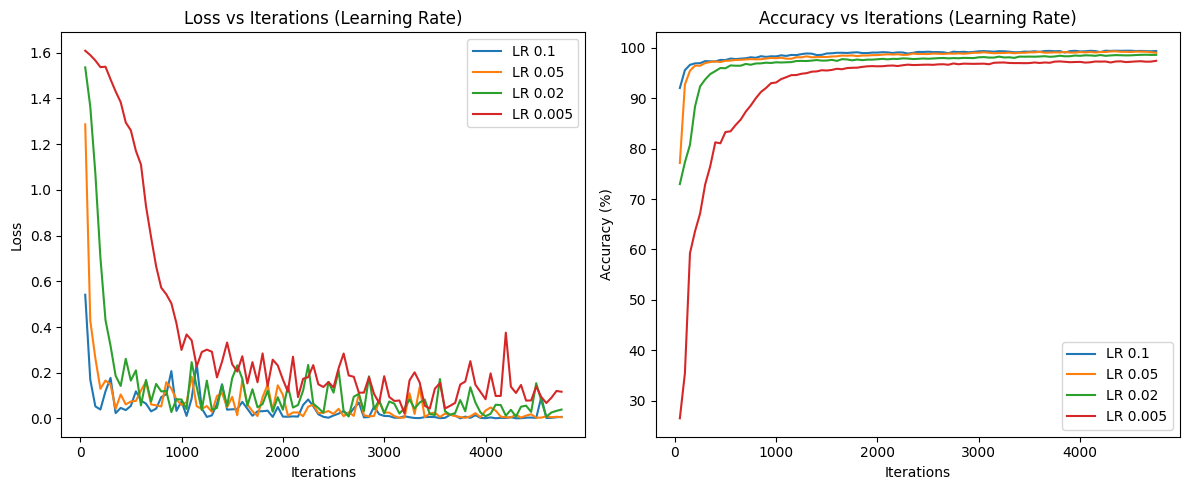

In [15]:
# 실험 2 모델 학습 결과 시각화
## 답안 ##
plt.figure(figsize=(12,5))
# loss 시각화
plt.subplot(1, 2, 1)
for learning_rate, (iters, losses, accs) in results.items():
    plt.plot(iters, losses, label=f'LR {learning_rate}')

plt.title('Loss vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()


# accuracy 시각화
plt.subplot(1, 2, 2)
for learning_rate, (iters, losses, accs) in results.items():
    plt.plot(iters, accs, label=f'LR {learning_rate}')

plt.title('Accuracy vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

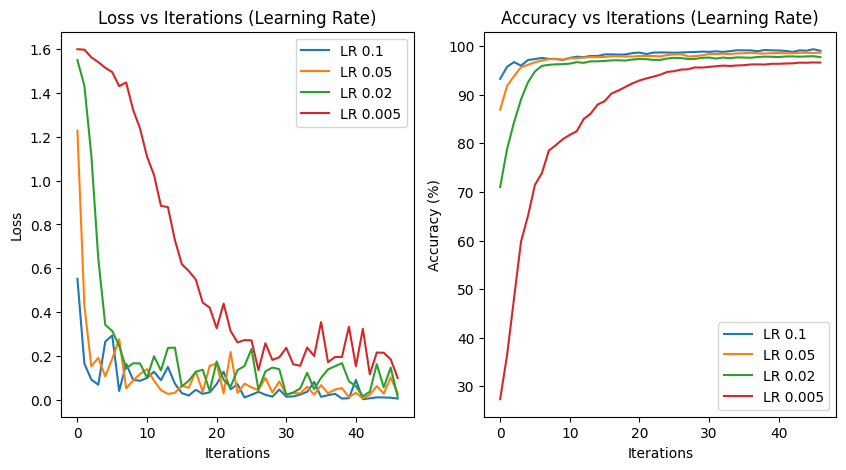

In [ ]:
# 실험 2 모델 학습 결과 시각화
## 답안 ##

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- learning rate값이 작을수록 loss값의 값소량이 줄어들고 수렴하는 값이 크다.
- learning rate값이 작을수록 정확도가 더 천천히 높아지고 수렴하는 정확도 값도 낮다.
- 이를 통해 learning rate가 너무 낮을 경우 모델 학습 속도가 느려지며 이로인해 모델의 성능애 부정적 영향을 끼칠 수 있음을 확인할 수 있다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)


        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [26]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [27]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 8 # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        #답안#
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.argmax(outputs, dim=1)

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.417716419763692
Epoch 2, Loss: 0.12933977535733318
Epoch 3, Loss: 0.10583401947391136
Epoch 4, Loss: 0.0920585036493589
Epoch 5, Loss: 0.08072605424940718
Epoch 6, Loss: 0.07163282980489115
Epoch 7, Loss: 0.06485374184175383
Epoch 8, Loss: 0.059037512743802804


#### **CNN 학습 결과**

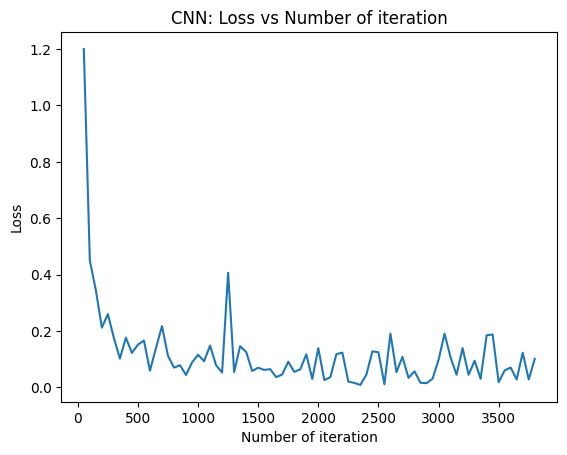

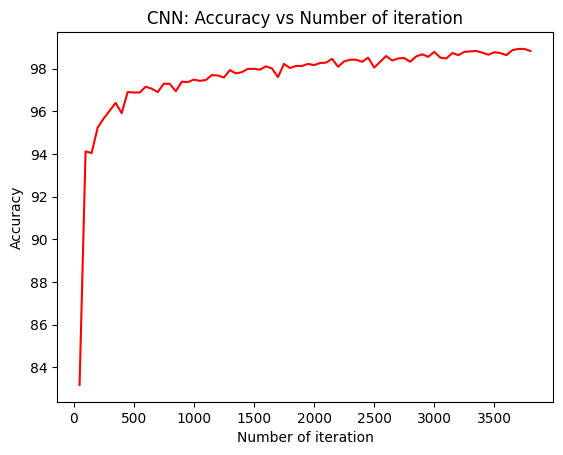

In [28]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
-
- ANN과 CNN모델의 iteration횟수를 4000으로 맞추기 위해 8번의 CNN의 epoch로 학습시킨 결과를 비교했다.
- 학습 결과는 ann모델이 cnn모델에 비해 1000번째 iteration에서 loss기울기가 먼저 평평해지고 loss값의 변동성이 안정된 모습을모습을 보이지만 cnn모델은 ann모델에 비해 accuracy기울기가 3000번대의 학습 단계에서도 더 가파르게 변화하는 모습을 통해 ann모델은 4000번의 iteration끝에 수렴 지점에 도착해 더이상 학습은 과적합으로 이어지는 단계에 도착한것에 비해 CNN은 아직 학습이 진행되고 있는 단계임을 알 수 있다.
- 아직 학습이 진행되고 있는 단계임에도 불구하고 cnn모델에서 조금 더 높은 정확도 값으로 수렴되고 있는 모습을 확인할 수 있다.
- ANN모델은 뇌 신경망을 모방한 가장 기본적인 형태의 딥러닝 모델로 fully connected layer들로 구성되어 있으며 이미지의 공간적 구조의 위치를 무시한다는 단점이 있다.
- cnn모델은 이미지의 공간 정보를 보존하며 학습하기 위해 고안된 모델로 필터를 통해 이미지의 특징을 추출하는 합성곱 연산을 수행한다.
- 변동성이 cnn모델이 ann모델보다 더 크로 더 많은 반복 이후에 CNN모델이 학습되는이유로는 이는 cnn모델이 데이터의 세부 특징에 더 민감하게 반응해 학습하는 과정이 노이즈로 나타나는것으로 예상할 수 있다.
